In [1]:
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(ggrepel)
library(SingleCellExperiment)
library(tidyverse)
library(Matrix)
library(scales)
library(cowplot)
library(RCurl)
library(harmony)
library(viridis)
library(SeuratObject)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count



Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantile

In [2]:
osteosarcoma_harmony <- readRDS("/mnt/d12b/SC_BONE_RAW/data/sample_merged_processed/osteosarcoma_harmony_khanh.rds")

In [3]:
osteosarcoma_harmony

An object of class Seurat 
33468 features across 48942 samples within 2 assays 
Active assay: SCT (16734 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 3 dimensional reductions calculated: pca, harmony, umap

In [4]:
Idents(osteosarcoma_harmony) <- osteosarcoma_harmony$SCT_snn_res.0.6

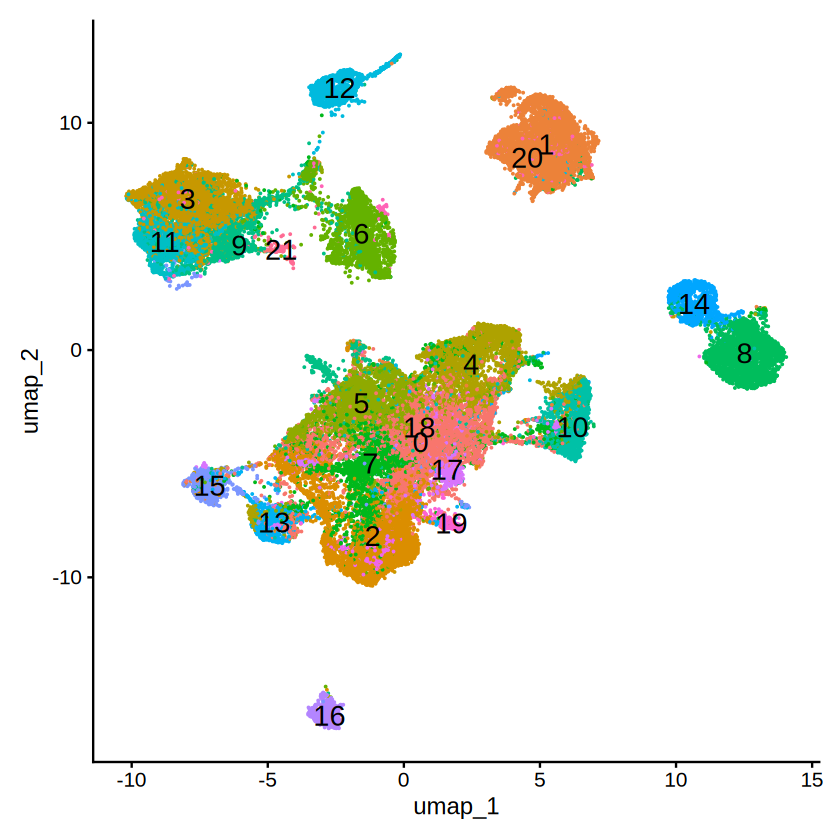

In [5]:
DimPlot(osteosarcoma_harmony, label =TRUE, label.size = 6) + NoLegend()

In [6]:
all_markers <- list(
    OS = c("COL1A1", "COL5A1", "RUNX2", "CDH11", "TOP2A", "PCNA", "MKI67", "TYMS", "COL2A1", "MMP13", "ITGA10"),
    OC = c("CTSK", "MMP9","ACP5", "ITGB3", "RUFY4","JDP2"),
    TILs = c("CD3D", "IL7R", "NKG7","CD8A","CD4","PTPRC","CYTIP","TMC8","ZAP70","ACAP1"),
    Myeloid = c("CD74", "CD14", "FCGR3A","CD163","MS4A7","CYTH4","MS4A6A"),
    Fibroblast = c("LUM", "DCN", "COL6A3", "THBS4", "FBLN1", "COL14A1", "MYL9"),
    Pericyte = c("ACTA2", "RGS5", "PDGFRB","MCAM","NOTCH3","CDH2"),
    MSC = c("CXCL12", "SFRP2", "MME", "THY1","NT5E","VEGFA","TGFBI","CXCL14","SPP1","CLEC11A","IBSP"),
    Myoblast = c("MYLPF", "MYL1", "MYBPC2","LDB3","ACTA1","TNNI2"),
    EC = c("PECAM1", "VWF", "COL18A1","EGFL7","SHANK3","PLVAP","AFAP1L1")
)

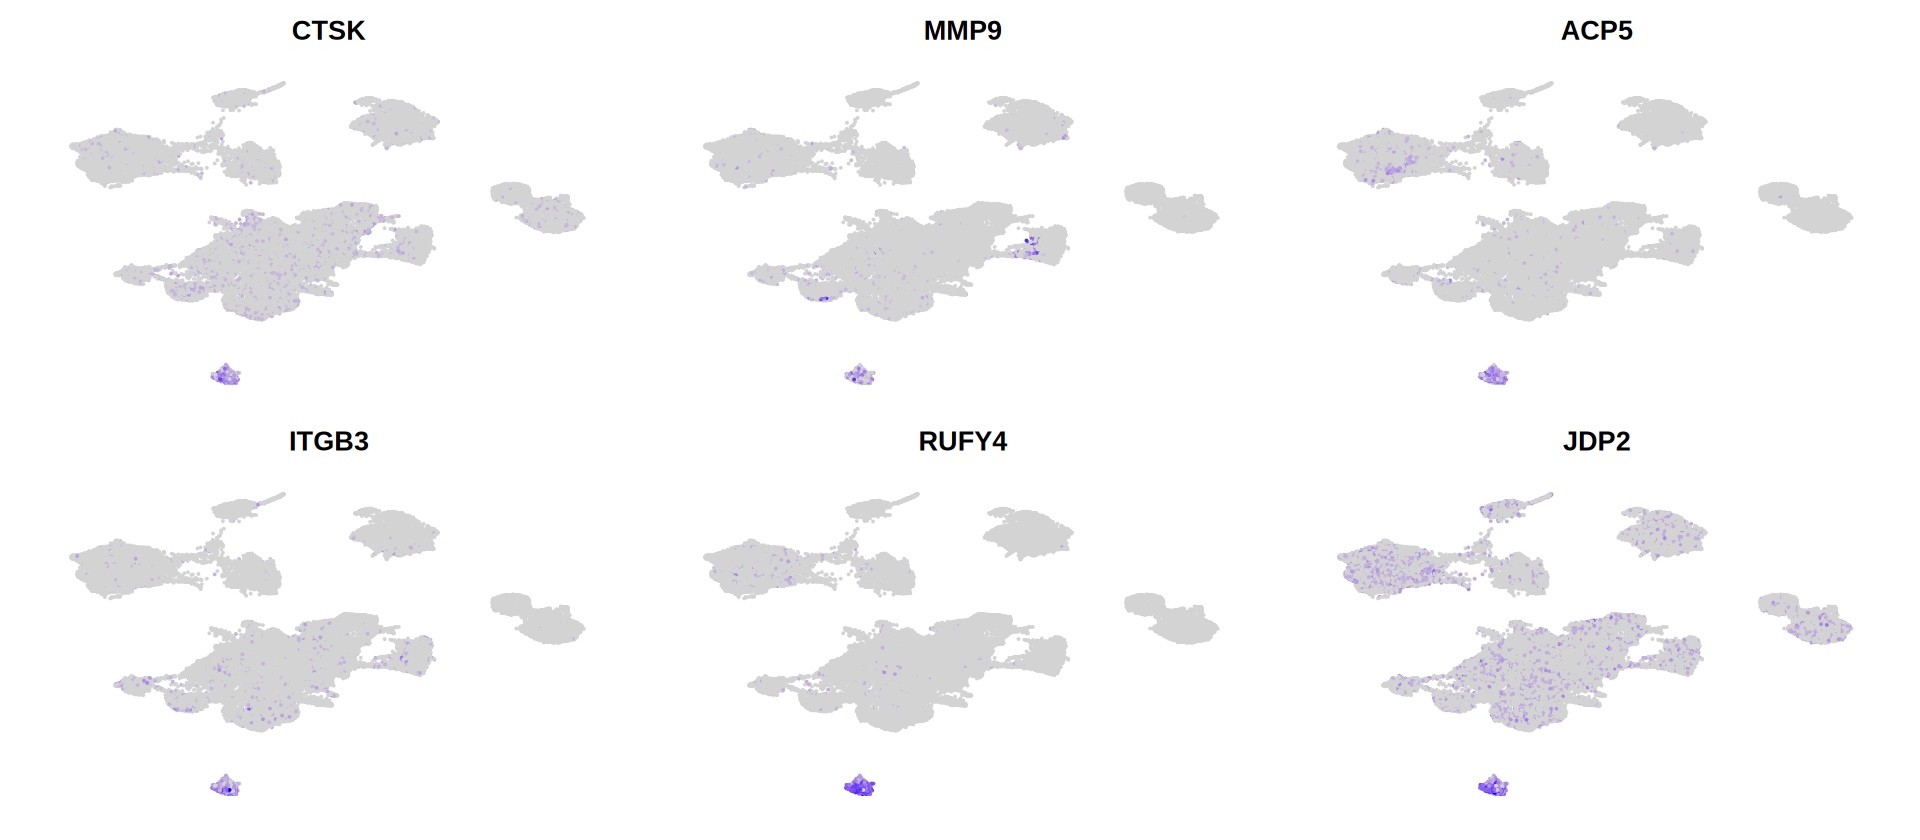

In [7]:
options(repr.plot.width = 16, repr.plot.height = 7)

FeaturePlot(
    object = osteosarcoma_harmony, 
    features = all_markers[["OC"]], 
    combine = TRUE,
    ncol = 3
    ) & NoLegend() & NoAxes()

In [8]:
osteosarcoma_harmony@meta.data |> head()

,orig.ident,nCount_RNA,nFeature_RNA,seq_folder,nUMI,nGene,log10GenesPerUMI,mitoRatio,cells,nCount_SCT,nFeature_SCT,SCT_snn_res.0.1,SCT_snn_res.0.2,SCT_snn_res.0.4,SCT_snn_res.0.5,SCT_snn_res.0.6,SCT_snn_res.0.8,SCT_snn_res.1,SCT_snn_res.1.2,seurat_clusters
,<fct>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
treated_1_AAACAAGCACTAGCGGATGTTGAC-1,treated,2157,1411,treated_1,2159,1413,0.9447821,0.00000000,treated_1_AAACAAGCACTAGCGGATGTTGAC-1,1645,1390,8,11,15,16,16,19,24,20,20
treated_1_AAACCAATCACAAATGATGTTGAC-1,treated,798,457,treated_1,798,457,0.9165794,0.00000000,treated_1_AAACCAATCACAAATGATGTTGAC-1,877,457,0,4,5,5,4,5,2,4,4
treated_1_AAACCAATCATTACCGATGTTGAC-1,treated,876,712,treated_1,876,712,0.9694056,0.00000000,treated_1_AAACCAATCATTACCGATGTTGAC-1,880,712,2,3,2,1,1,9,8,8,8
treated_1_AAACCAGGTCAATTGCATGTTGAC-1,treated,1145,686,treated_1,1146,687,0.9273572,0.03664921,treated_1_AAACCAGGTCAATTGCATGTTGAC-1,1128,686,0,2,8,8,7,8,5,5,5
treated_1_AAACGGGCACTCCCAAATGTTGAC-1,treated,700,517,treated_1,700,517,0.9537424,0.00000000,treated_1_AAACGGGCACTCCCAAATGTTGAC-1,817,517,0,10,14,14,15,16,19,2,2
treated_1_AAACTGGGTTGTGAGAATGTTGAC-1,treated,749,487,treated_1,749,487,0.9349612,0.00000000,treated_1_AAACTGGGTTGTGAGAATGTTGAC-1,833,487,0,0,0,0,17,5,23,22,22


## Load metadata

## Annotation

In [9]:
all_markers <- list(
    OS = c("COL1A1", "COL5A1", "COL3A1", "RUNX2", "CDH11", "TOP2A", "PCNA", "MKI67", "TYMS", "SOX9", "COL2A1", "ACAN", "MMP13", "ITGA10"),
    OC = c("CTSK", "ACP5", "ITGB3", "RUFY4","JDP2"),
    TILs = c("CD3D", "IL7R", "NKG7","CD8A","CD4","PTPRC","CYTIP","TMC8","ZAP70","ACAP1"),
    Myeloid = c("CD74", "CD14", "FCGR3A","CD163","MS4A7","CYTH4","MS4A6A"),
    Fibroblast = c("LUM", "DCN", "COL6A3", "THBS4", "FBLN1", "COL14A1", "MYL9"),
    Pericyte = c("ACTA2", "RGS5", "PDGFRB","MCAM","NOTCH3","CDH2"),
    MSC = c("CXCL12", "SFRP2", "MME", "THY1","NT5E","VEGFA","TGFBI","CXCL14","SPP1","CLEC11A","IBSP"),
    Myoblast = c("MYLPF", "MYL1", "MYBPC2","LDB3","ACTA1","TNNI2"),
    EC = c("PECAM1", "VWF", "COL18A1","EGFL7","SHANK3","PLVAP","AFAP1L1")
)

In [10]:
# Flatten the markers for DotPlot
markers_genes <- unlist(all_markers)
markers_genes <- make.unique(markers_genes)

# Set factor levels in the order of your original markers vector
markers_genes <- factor(markers_genes, levels = markers_genes)

# Create a mapping from gene -> "CellType:Gene" label
label_map <- unlist(
  lapply(names(all_markers), function(ct) {
    setNames(
      paste0(ct, ":", all_markers[[ct]]),  # e.g., "T_cells:CD3D"
      all_markers[[ct]]                   # the original gene name
    )
  })
)

In [11]:
Idents(osteosarcoma_harmony) <- "SCT_snn_res.0.6"

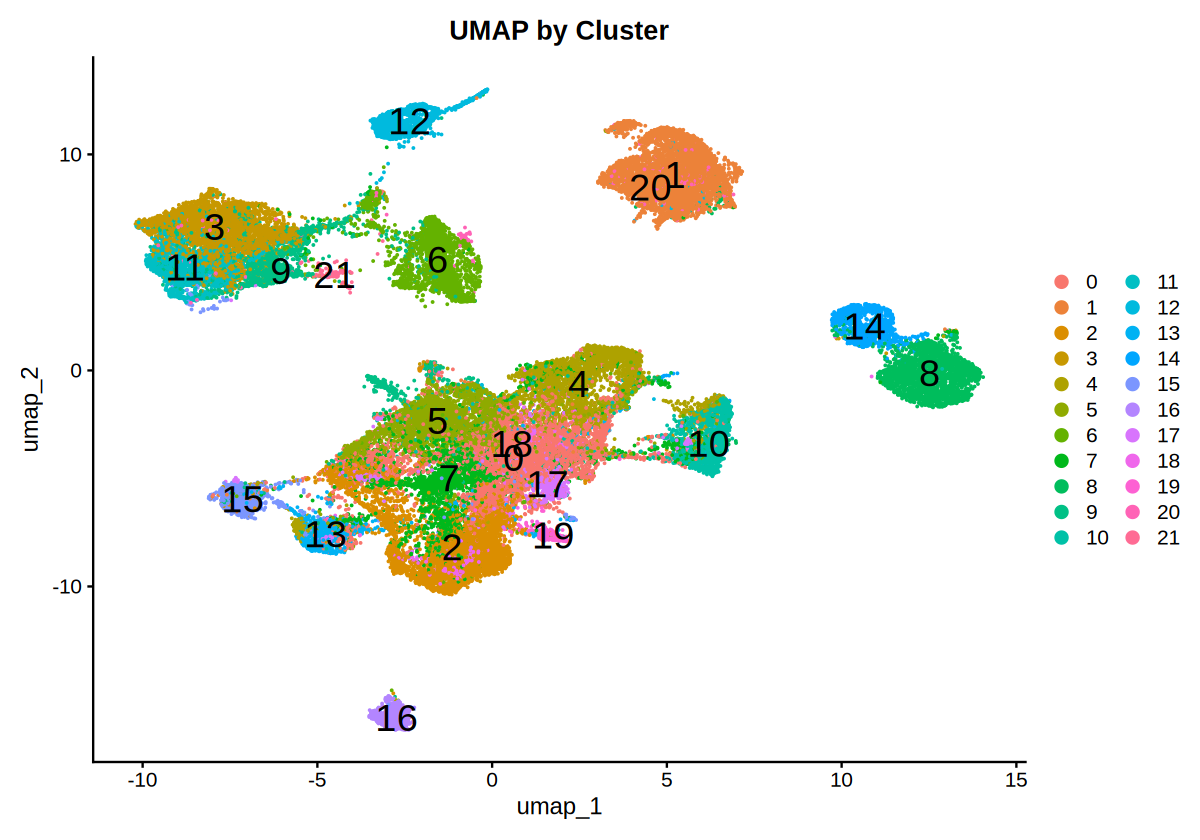

In [12]:
options(repr.plot.width = 10)

DimPlot(osteosarcoma_harmony, reduction = "umap", group.by = "SCT_snn_res.0.6", label=TRUE, label.size = 8) + 
    ggtitle("UMAP by Cluster")

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


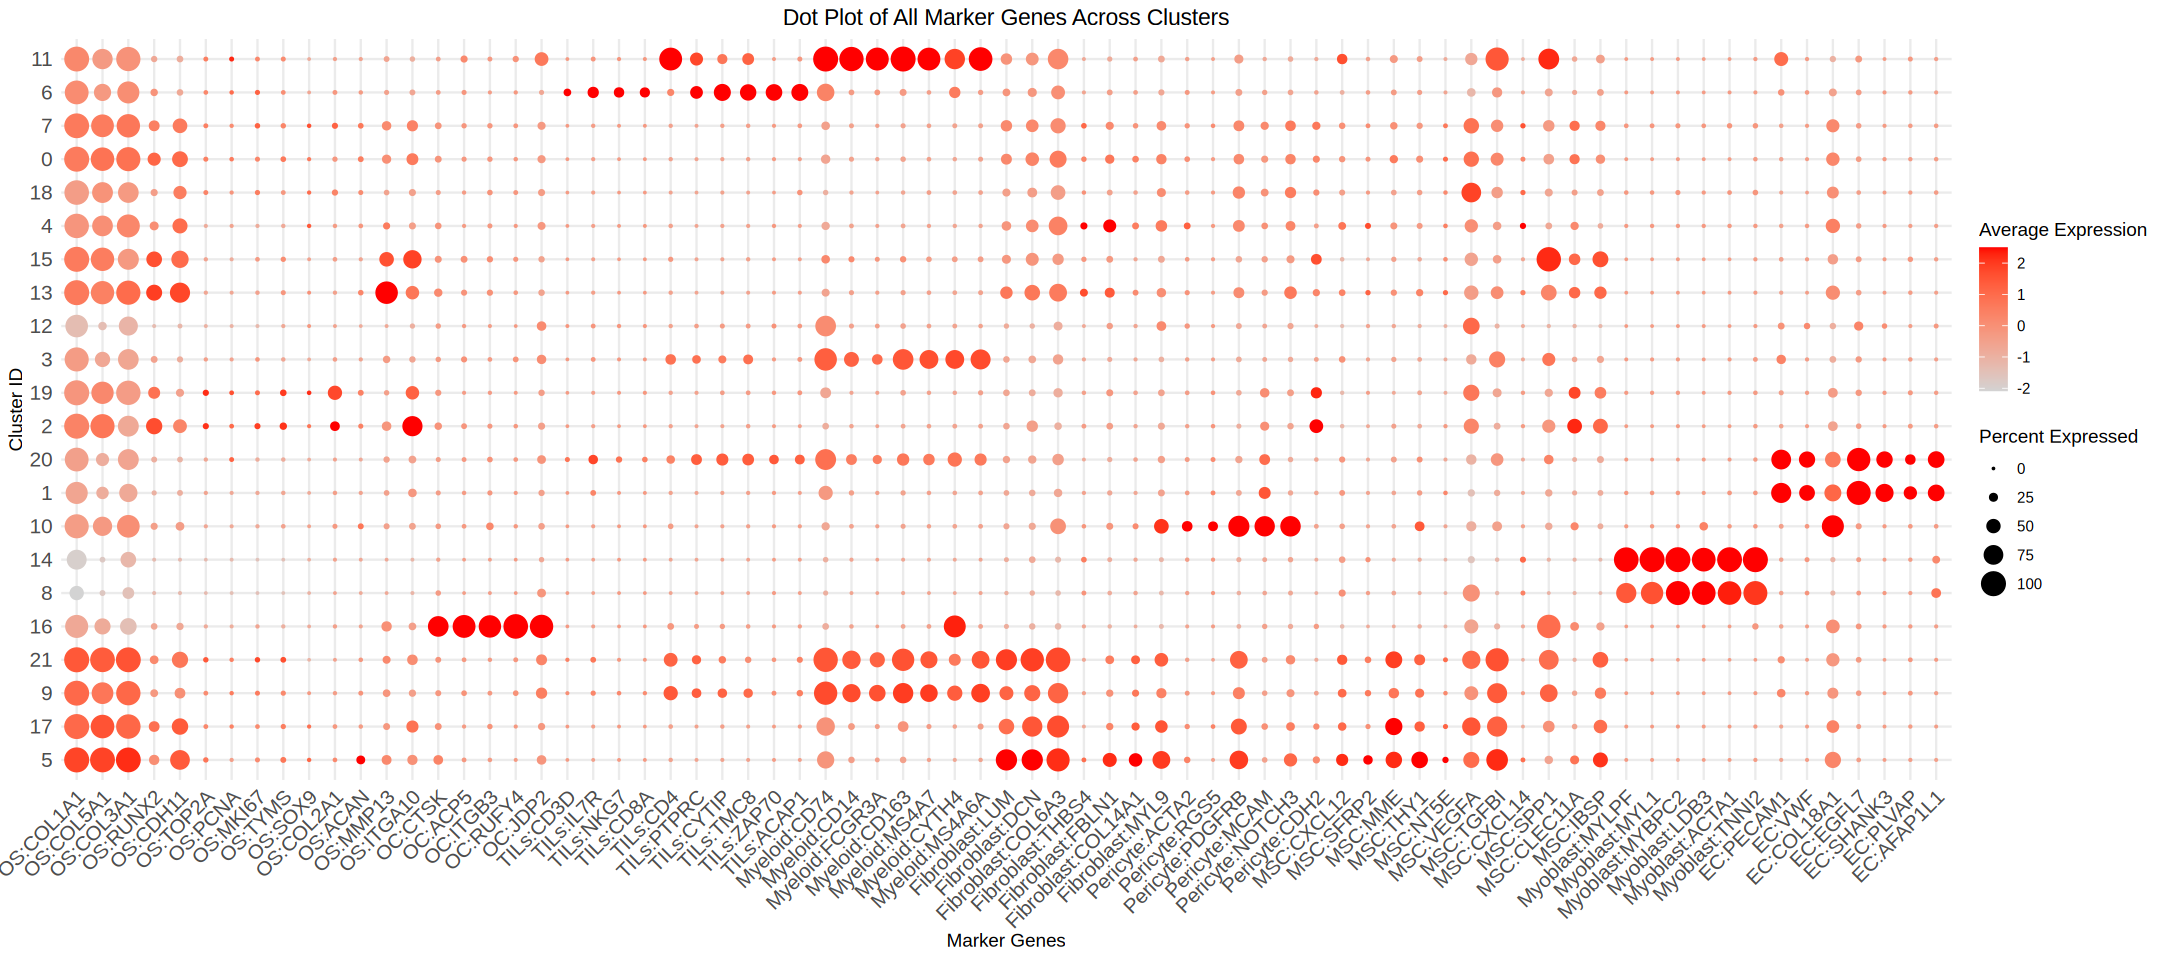

In [13]:
options(repr.plot.width = 18, repr.plot.height = 8)

library(Seurat)
library(ggplot2)

p <- DotPlot(osteosarcoma_harmony, features = markers_genes, cluster.idents = TRUE) +
  scale_color_gradient(low = "lightgrey", high = "red") +
  theme_minimal() +
  xlab("Marker Genes") +
  ylab("Cluster ID") +
  ggtitle("Dot Plot of All Marker Genes Across Clusters") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
    axis.text.y = element_text(size = 12),
    plot.title  = element_text(hjust = 0.5)
  ) +
  # Override labels so "CD3D" is displayed as "T_cells:CD3D", etc.
  scale_x_discrete(labels = label_map)

# Print the plot
p

In [14]:
library(dplyr)
library(tidyverse)

osteosarcoma_harmony@meta.data <- osteosarcoma_harmony@meta.data %>%
    mutate(cell_type = case_when(
        SCT_snn_res.0.6 %in% c(6) ~ "TILs",
        SCT_snn_res.0.6 %in% c(11,3,21,9) ~ "Myeloid",
        SCT_snn_res.0.6 %in% c(10) ~ "Pericyte",
        SCT_snn_res.0.6 %in% c(20,1) ~ "EC",
        SCT_snn_res.0.6 %in% c(7,0,18,4,15,13,19,2) ~ "OS",
        SCT_snn_res.0.6 %in% c(14,8) ~ "Myoblast",
        SCT_snn_res.0.6 %in% c(16) ~ "OC",
        SCT_snn_res.0.6 %in% c(17,5) ~ "Fibroblast",
        #SCT_snn_res.0.6 %in% c(9) ~ "MSC",
        # SCT_snn_res.0.6 %in% c(22) ~ "Other_TILs",
        # SCT_snn_res.0.6 %in% c(7) ~ "Other_Myoblast",
        # SCT_snn_res.0.6 %in% c(23) ~ "Others",
        TRUE ~ NA_character_
    ))

head(osteosarcoma_harmony@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,seq_folder,nUMI,nGene,log10GenesPerUMI,mitoRatio,cells,nCount_SCT,⋯,SCT_snn_res.0.1,SCT_snn_res.0.2,SCT_snn_res.0.4,SCT_snn_res.0.5,SCT_snn_res.0.6,SCT_snn_res.0.8,SCT_snn_res.1,SCT_snn_res.1.2,seurat_clusters,cell_type
,<fct>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>,<dbl>,<chr>,<dbl>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<chr>
treated_1_AAACAAGCACTAGCGGATGTTGAC-1,treated,2157,1411,treated_1,2159,1413,0.9447821,0.00000000,treated_1_AAACAAGCACTAGCGGATGTTGAC-1,1645,⋯,8,11,15,16,16,19,24,20,20,OC
treated_1_AAACCAATCACAAATGATGTTGAC-1,treated,798,457,treated_1,798,457,0.9165794,0.00000000,treated_1_AAACCAATCACAAATGATGTTGAC-1,877,⋯,0,4,5,5,4,5,2,4,4,OS
treated_1_AAACCAATCATTACCGATGTTGAC-1,treated,876,712,treated_1,876,712,0.9694056,0.00000000,treated_1_AAACCAATCATTACCGATGTTGAC-1,880,⋯,2,3,2,1,1,9,8,8,8,EC
treated_1_AAACCAGGTCAATTGCATGTTGAC-1,treated,1145,686,treated_1,1146,687,0.9273572,0.03664921,treated_1_AAACCAGGTCAATTGCATGTTGAC-1,1128,⋯,0,2,8,8,7,8,5,5,5,OS
treated_1_AAACGGGCACTCCCAAATGTTGAC-1,treated,700,517,treated_1,700,517,0.9537424,0.00000000,treated_1_AAACGGGCACTCCCAAATGTTGAC-1,817,⋯,0,10,14,14,15,16,19,2,2,OS
treated_1_AAACTGGGTTGTGAGAATGTTGAC-1,treated,749,487,treated_1,749,487,0.9349612,0.00000000,treated_1_AAACTGGGTTGTGAGAATGTTGAC-1,833,⋯,0,0,0,0,17,5,23,22,22,Fibroblast


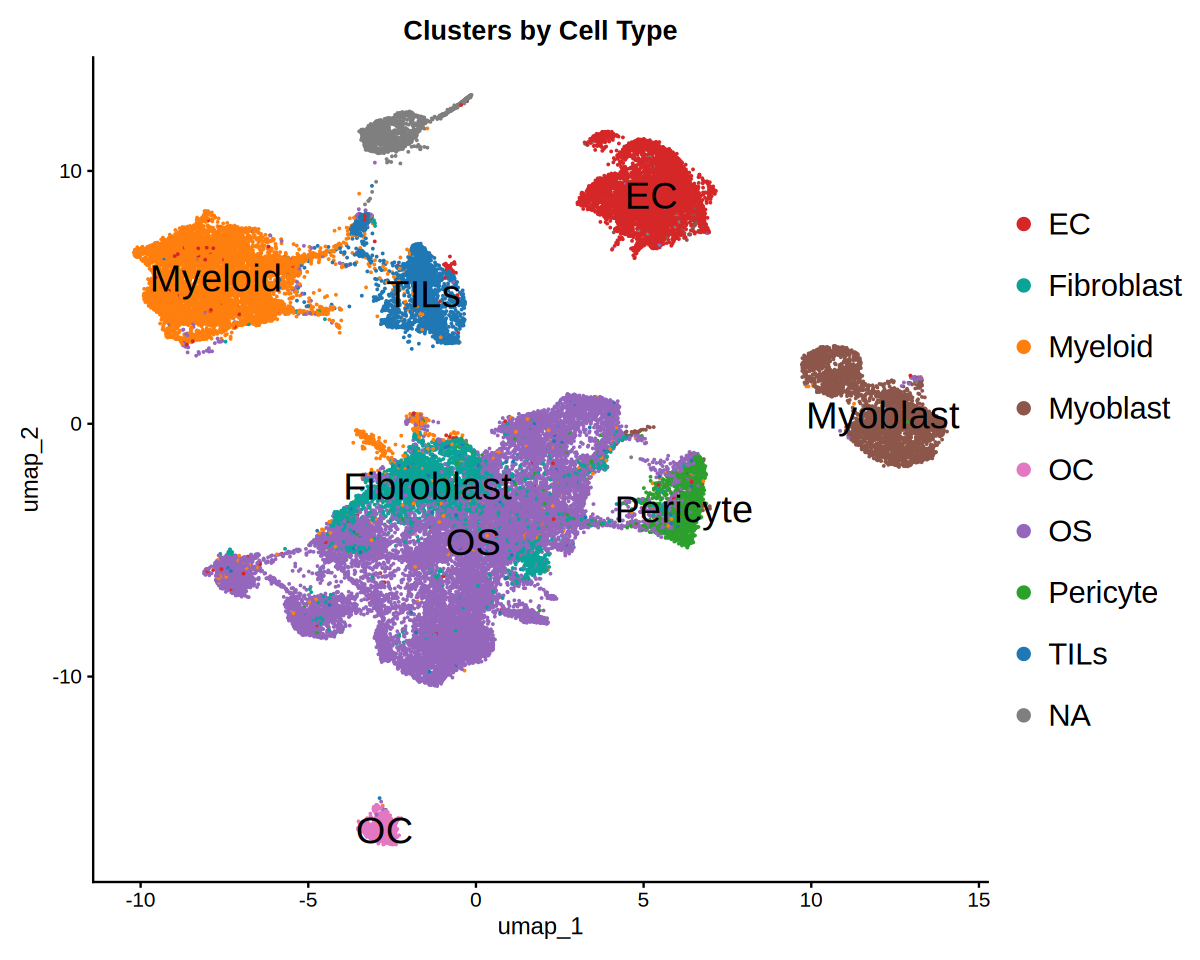

In [15]:
options(repr.plot.width = 10)

DimPlot(osteosarcoma_harmony, reduction = "umap", group.by = "cell_type", label = TRUE, label.size = 8) + 
    ggtitle("Clusters by Cell Type") +
    scale_color_manual(values = c(
        "TILs" = "#1f77b4",
        "Myeloid" = "#ff7f0e",
        "Pericyte" = "#2ca02c",
        "EC" = "#d62728",
        "OS" = "#9467bd",
        "Myoblast" = "#8c564b",
        "OC" = "#e377c2",
        "Fibroblast" = "#0ba397",
        "MSC" = "#bcbd22",
        "Other_TILs" = "#17becf",
        "Other_Myoblast" = "#aec7e8",
        "Others" = "#ffbb78"
    )) +
    theme(
        legend.text = element_text(size = 18), # Adjust size as needed
        legend.title = element_text(size = 14), # Optionally adjust legend title size
        legend.key.height = unit(1.3, "cm") # Make legend items sparser
    )


In [ ]:
#saveRDS(osteosarcoma_harmony,"/mnt/d12b/SC_BONE_RAW/data/sample_merged_processed/osteosarcoma_harmony_annotated.rds")

## Test the lung markers

In [16]:
lung_markers <- list(
    Lung_AT1 = c("AGER", "PDPN", "HOPX"),
    Lung_AT2 = c("SFTPC", "SFTPA1", "ABCA3"),
    Lung_Basal = c("KRT5", "KRT14", "TP63"),
    Lung_Club = c("SCGB1A1", "SCGB3A2", "BPIFA1"),
    Lung_ciliated = c("FOXJ1", "TUBB4B", "DNAH5"),
    Lung_goblet = c("MUC5AC", "MUC5B", "SPDEF"),
    Lung_AveMac = c("MARCO", "CD68"),
    #Lung_fibroblast = c("COL1A1", "COL3A1", "PDGFRA"),
    Lung_myofibroblasts = c("TAGLN", "VIM")
)

In [17]:
# Flatten the markers for DotPlot
lung_markers_genes <- unlist(lung_markers)
lung_markers_genes <- make.unique(lung_markers_genes)

# Set factor levels in the order of your original markers vector
lung_markers_genes <- factor(lung_markers_genes, levels = lung_markers_genes)

# Create a mapping from gene -> "CellType:Gene" label
label_map <- unlist(
  lapply(names(lung_markers), function(ct) {
    setNames(
      paste0(ct, ":", lung_markers[[ct]]),  # e.g., "T_cells:CD3D"
      lung_markers[[ct]]                   # the original gene name
    )
  })
)

In [18]:
Idents(osteosarcoma_harmony) <- "SCT_snn_res.0.6"

Warning message:
“The following requested variables were not found: BPIFA1”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


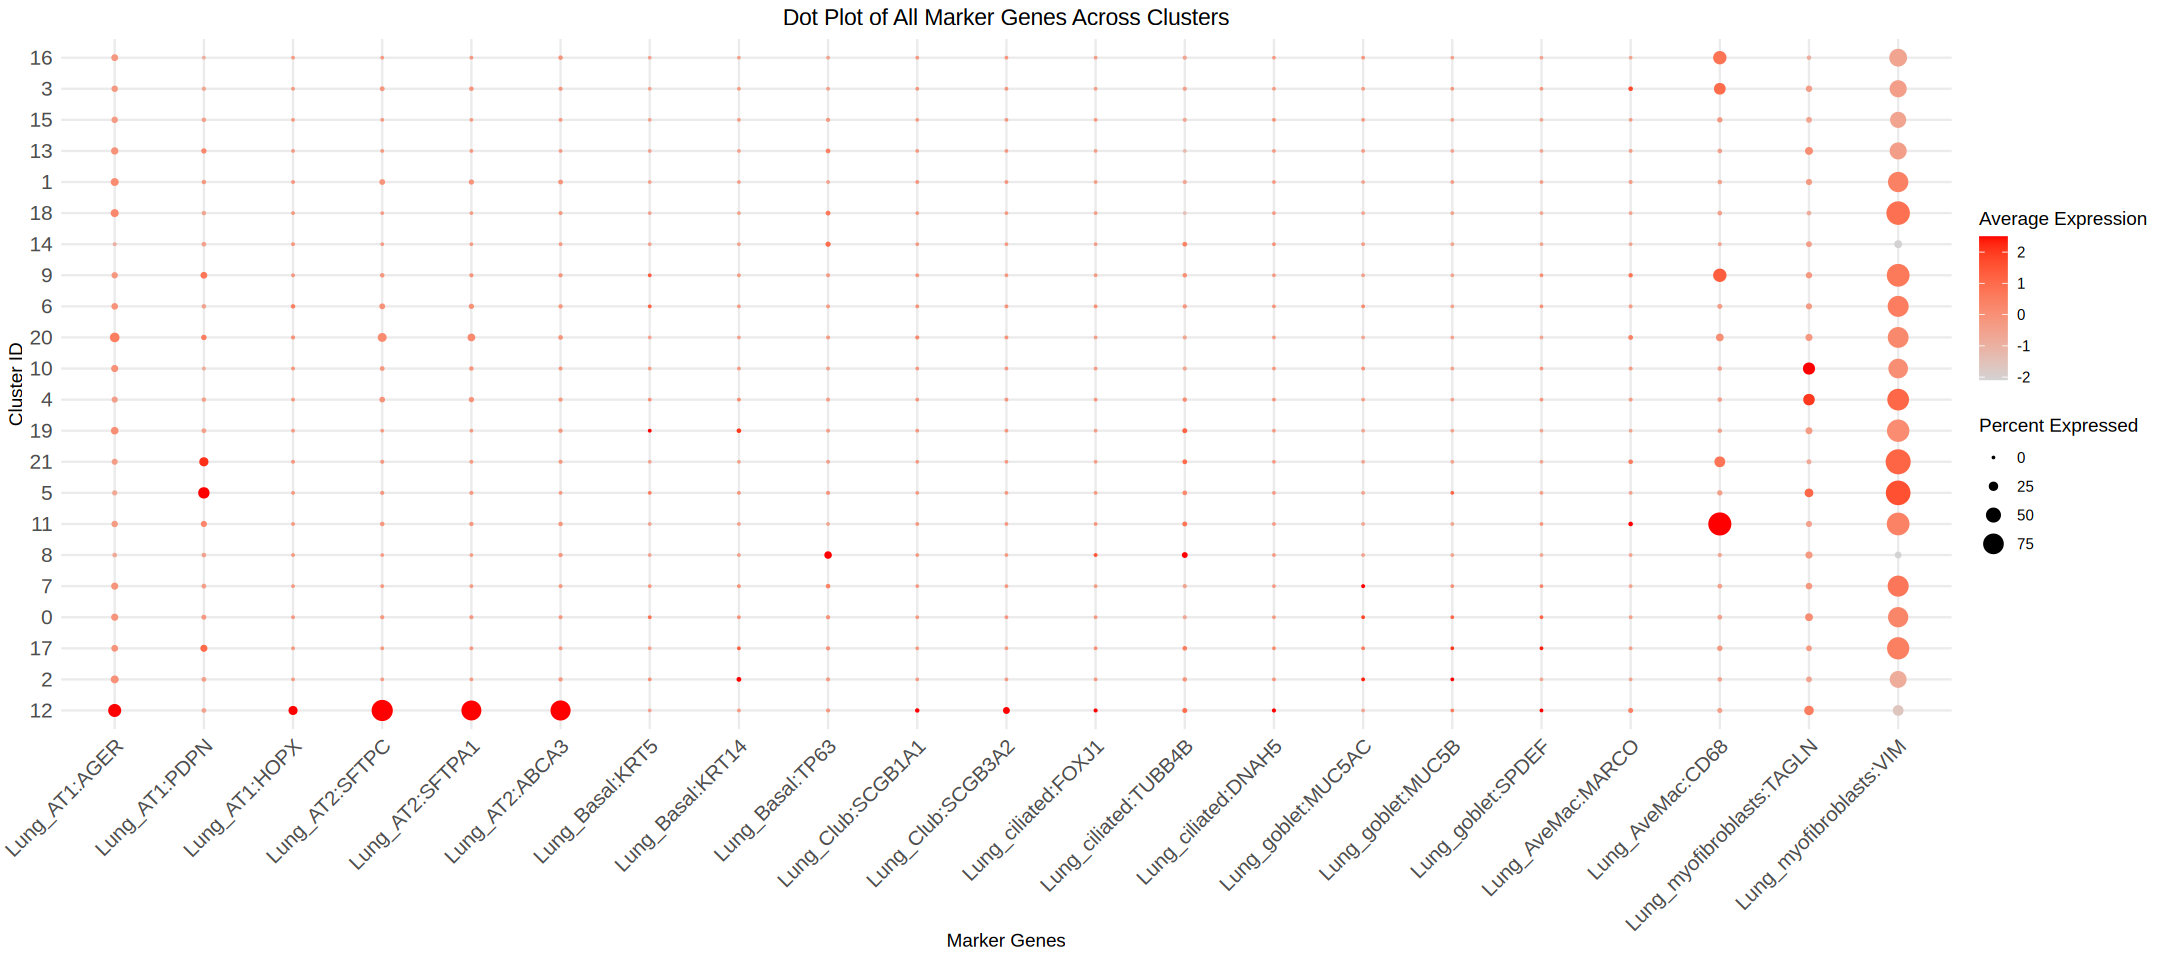

In [19]:
options(repr.plot.width = 18, repr.plot.height = 8)

library(Seurat)
library(ggplot2)

p <- DotPlot(osteosarcoma_harmony, features = lung_markers_genes, cluster.idents = TRUE) +
  scale_color_gradient(low = "lightgrey", high = "red") +
  theme_minimal() +
  xlab("Marker Genes") +
  ylab("Cluster ID") +
  ggtitle("Dot Plot of All Marker Genes Across Clusters") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
    axis.text.y = element_text(size = 12),
    plot.title  = element_text(hjust = 0.5)
  ) +
  # Override labels so "CD3D" is displayed as "T_cells:CD3D", etc.
  scale_x_discrete(labels = label_map)

# Print the plot
p

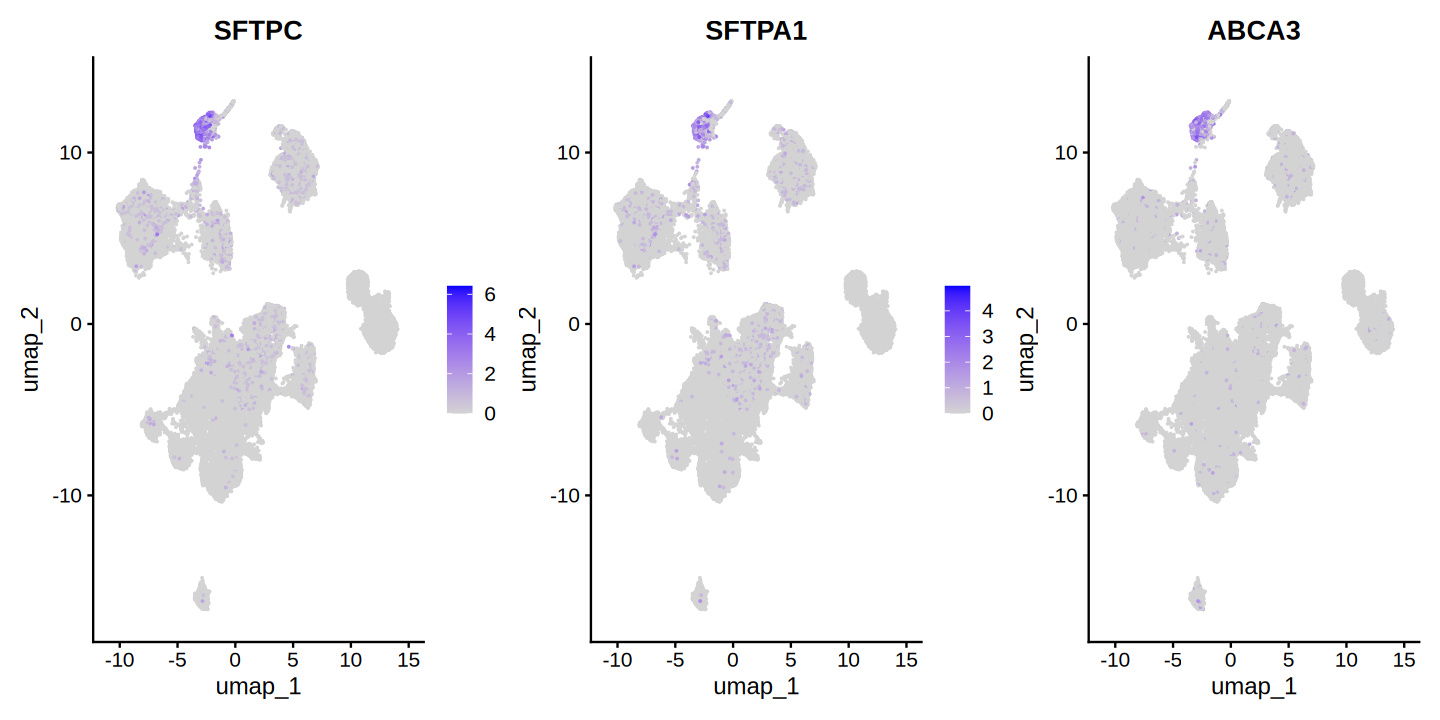

In [20]:
options(repr.plot.width = 12, repr.plot.height = 6)
FeaturePlot(osteosarcoma_harmony, features = c("SFTPC","SFTPA1","ABCA3"),ncol=3) + NoLegend()

## Detail analysis of cluster’s markers

### Dot plot of cell-type

In [21]:
Idents(osteosarcoma_harmony) <- "cell_type"

#### Remove NA cell_type (cluster 12)

In [22]:
osteosarcoma_harmony_cell_type <- osteosarcoma_harmony

In [23]:
osteosarcoma_harmony_cell_type@meta.data <- osteosarcoma_harmony_cell_type@meta.data %>% filter(!is.na(cell_type))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


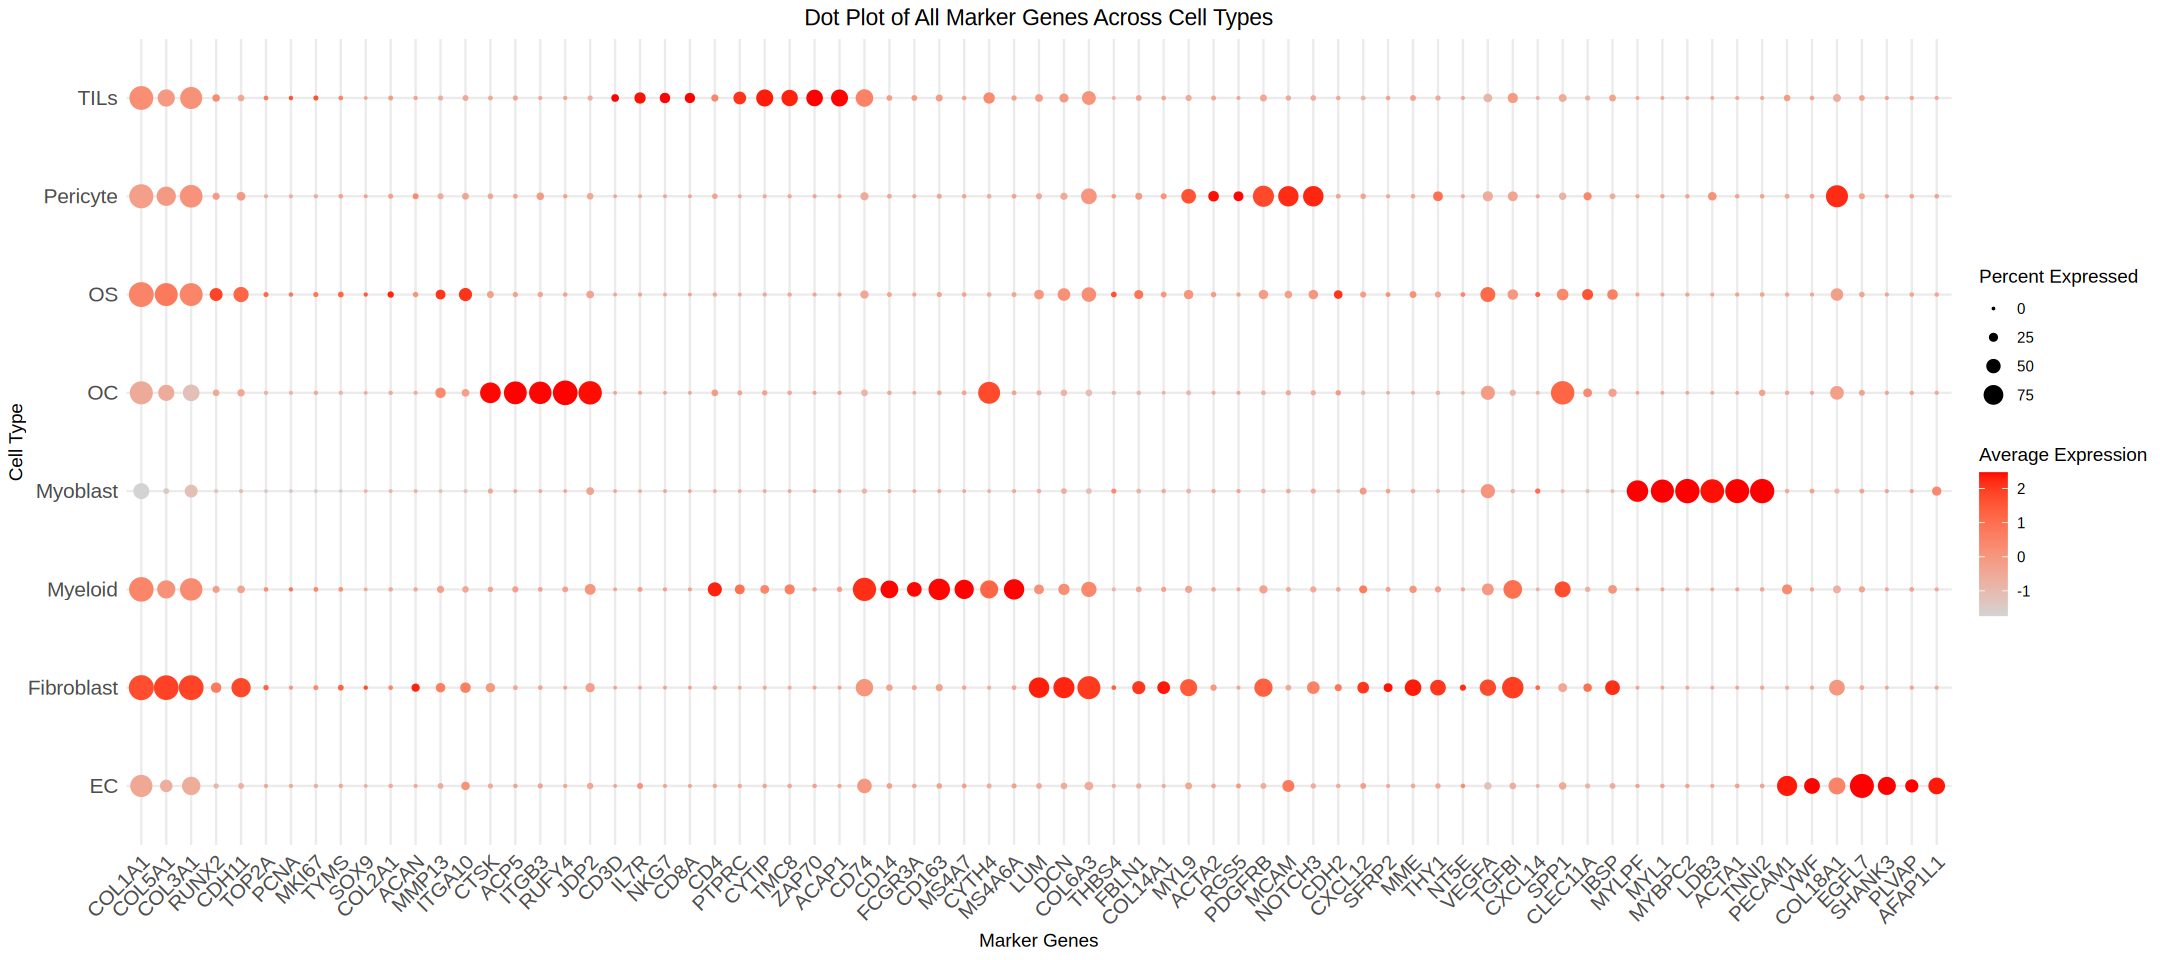

In [24]:
options(repr.plot.width = 18, repr.plot.height = 8)

p <- DotPlot(osteosarcoma_harmony_cell_type, features = markers_genes, group.by = "cell_type") +
    scale_color_gradient(low = "lightgrey", high = "red") +
    theme_minimal() +
    xlab("Marker Genes") +
    ylab("Cell Type") +
    ggtitle("Dot Plot of All Marker Genes Across Cell Types") +
    theme(
        axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
        axis.text.y = element_text(size = 12),
        plot.title  = element_text(hjust = 0.5)
    ) +
    # Override labels so "CD3D" is displayed as "T_cells:CD3D", etc.
    scale_x_discrete(labels = label_map)

# Print the plot
p

### Dimplot after remove NA cell_type

In [25]:
osteosarcoma_harmony@meta.data$SCT_snn_res.0.6 |> table()


   0    1    2    3    4    5    6    7    8    9   10   11   12   13   14   15 
6803 5421 4541 4315 3472 3345 2943 2726 2588 2228 1941 1643 1253 1103 1063 1045 
  16   17   18   19   20   21 
 720  544  488  376  259  125 

In [26]:
Idents(osteosarcoma_harmony) <- "SCT_snn_res.0.6"

In [27]:
# Cells in the cluster to exclude
cells_to_exclude <- WhichCells(osteosarcoma_harmony, idents = "12")
# Specify only the cells you want to keep
cells_to_keep <- setdiff(Cells(osteosarcoma_harmony), cells_to_exclude)


In [29]:
#cells_to_keep <- setdiff(Cells(osteosarcoma_harmony), cells_to_exclude)
osteosarcoma_harmony_subset <- subset(osteosarcoma_harmony, cells = cells_to_keep)

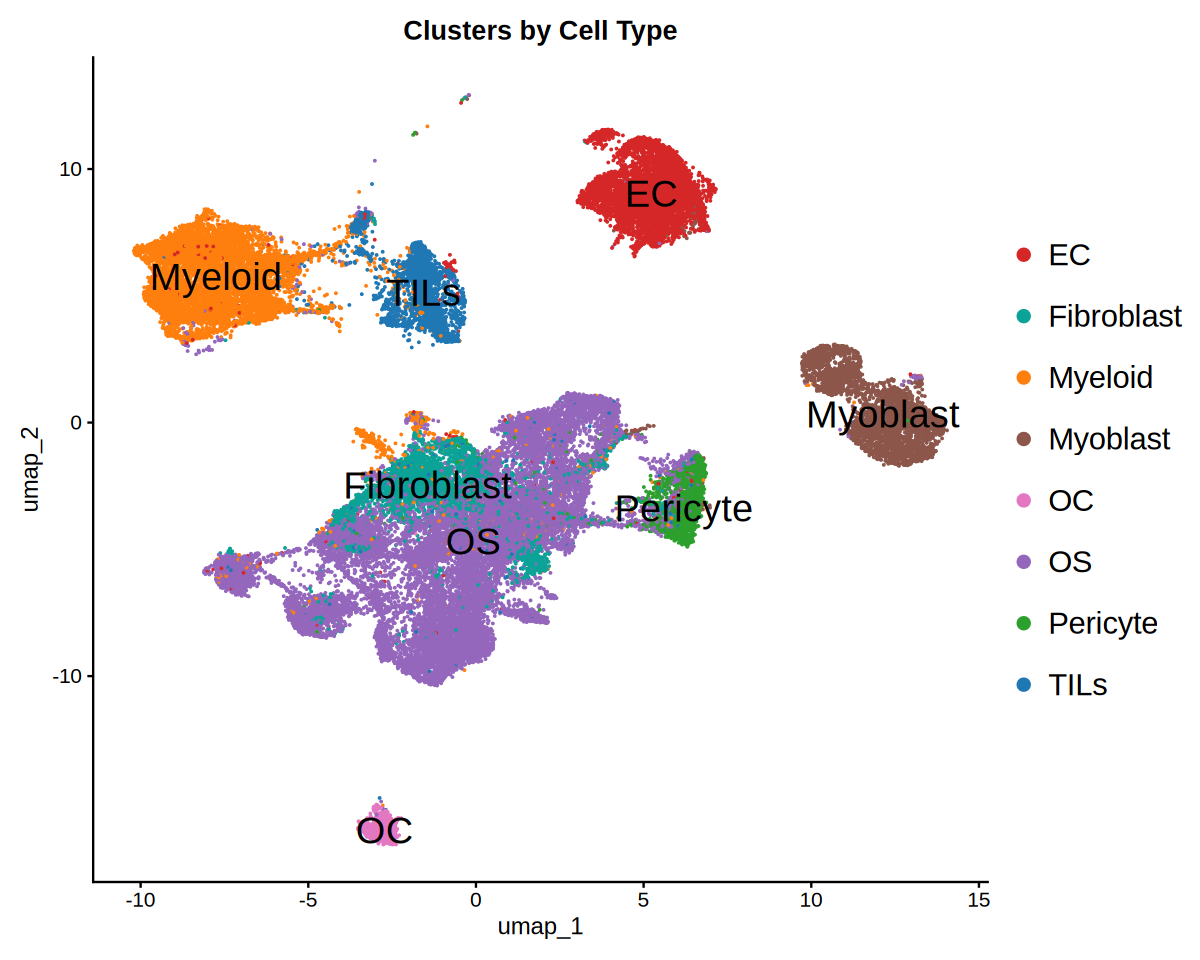

In [30]:
options(repr.plot.width = 10)

DimPlot(osteosarcoma_harmony_subset, reduction = "umap", group.by = "cell_type", label = TRUE, label.size = 8) + 
    ggtitle("Clusters by Cell Type") +
    scale_color_manual(values = c(
        "TILs" = "#1f77b4",
        "Myeloid" = "#ff7f0e",
        "Pericyte" = "#2ca02c",
        "EC" = "#d62728",
        "OS" = "#9467bd",
        "Myoblast" = "#8c564b",
        "OC" = "#e377c2",
        "Fibroblast" = "#0ba397",
        "MSC" = "#bcbd22",
        "Other_TILs" = "#17becf",
        "Other_Myoblast" = "#aec7e8",
        "Others" = "#ffbb78"
    )) +
    theme(
        legend.text = element_text(size = 18), # Adjust size as needed
        legend.title = element_text(size = 14), # Optionally adjust legend title size
        legend.key.height = unit(1.3, "cm") # Make legend items sparser
    )

## More evaluation

## Visualization

### VlnPlot (Violin Plot)

In [46]:
all_markers[["OS"]][1:6]

[1] "COL1A1" "COL5A1" "COL3A1" "RUNX2"  "CDH11"  "TOP2A"

In [31]:
#cells_to_keep <- setdiff(Cells(osteosarcoma_harmony), cells_to_exclude)
#osteosarcoma_harmony_subset <- subset(osteosarcoma_harmony, cells = cells_to_keep)

In [48]:
all_markers |> names()

[1] "OS"         "OC"         "TILs"       "Myeloid"    "Fibroblast"
[6] "Pericyte"   "MSC"        "Myoblast"   "EC"

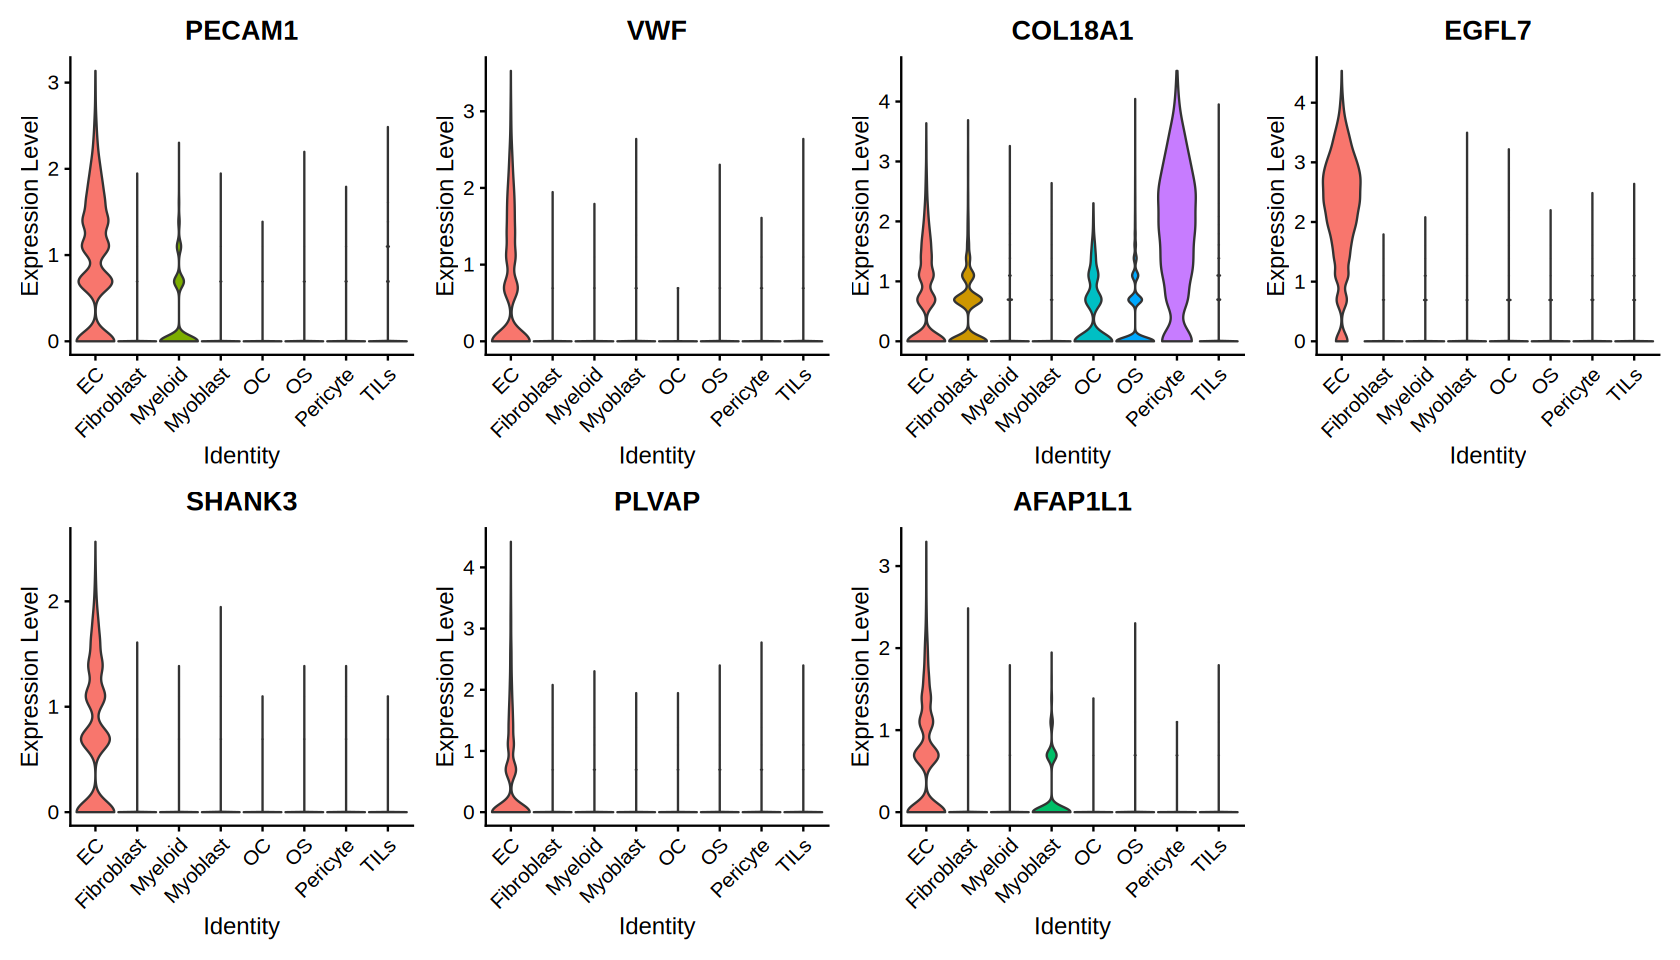

In [49]:
options(repr.plot.width = 14, repr.plot.height=8)

# Violin plot for multiple genes with no jitter
VlnPlot(
  object = osteosarcoma_harmony_subset, 
  features = all_markers[["EC"]],   # Replace with your genes
  group.by = "cell_type", 
  pt.size = 0, 
  ncol = 4
)

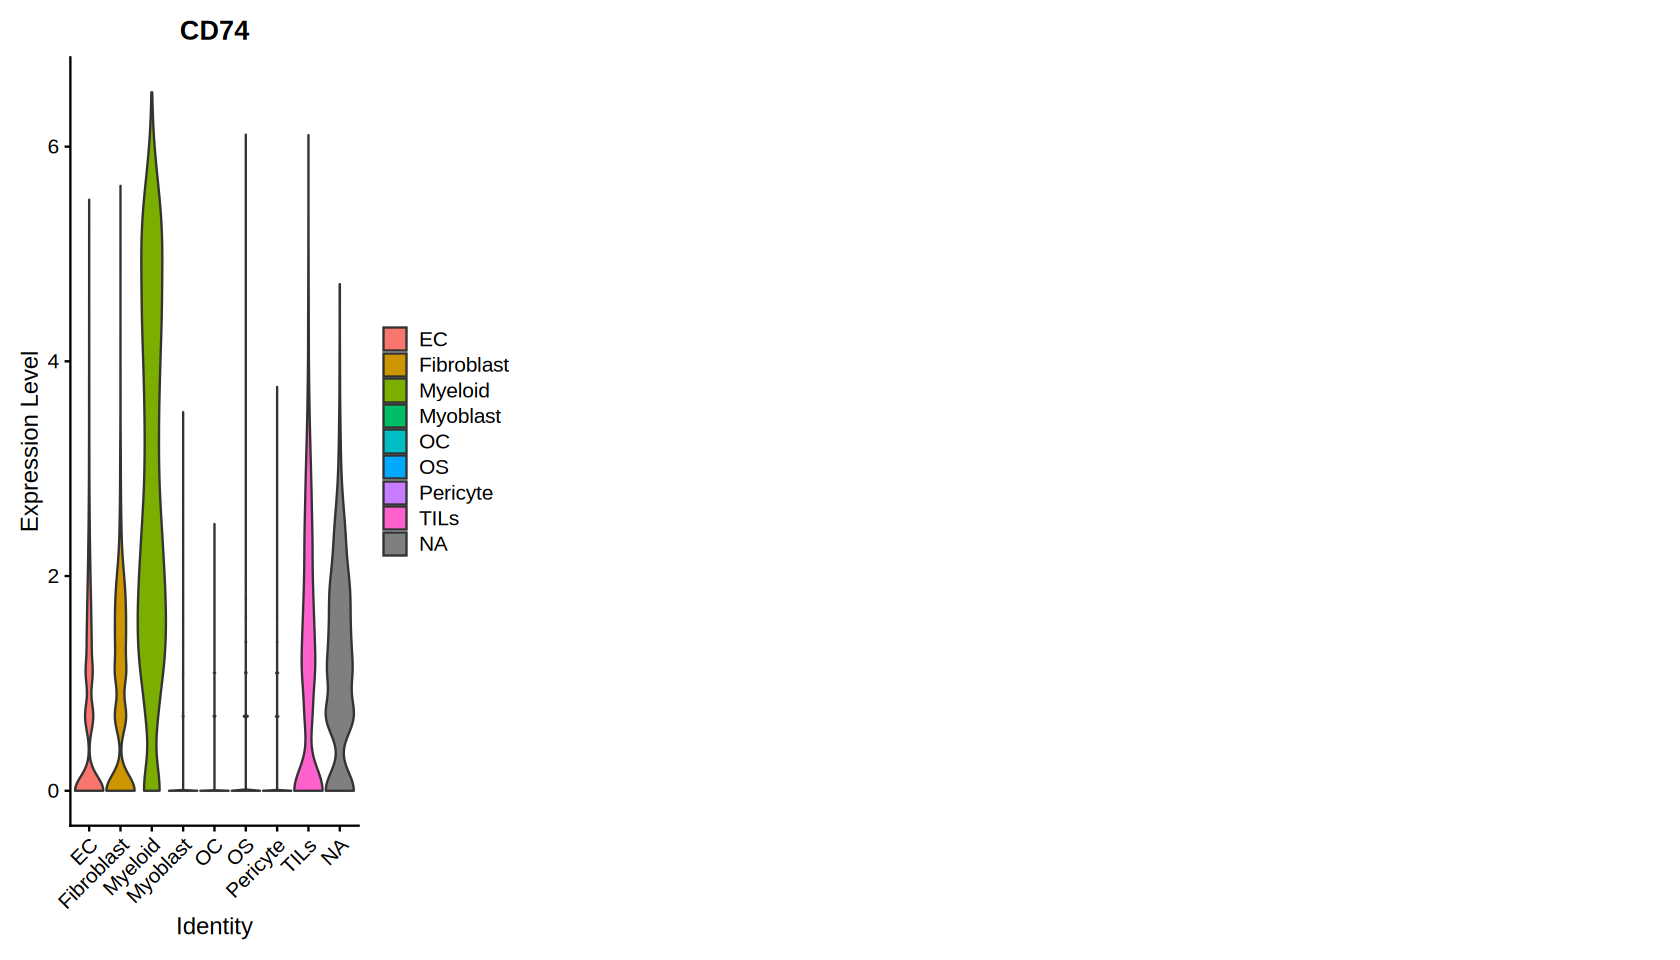

In [50]:
options(repr.plot.width = 14)

# Violin plot for multiple genes with no jitter
VlnPlot(
  object = osteosarcoma_harmony, 
  features = "CD74",   # Replace with your genes
  group.by = "cell_type", 
  pt.size = 0, 
  ncol = 5
)

In [ ]:
### Cell Composition

In [50]:
data <- osteosarcoma_harmony_subset@meta.data |> select(c(orig.ident,seq_folder,cell_type))

In [51]:
data |> head()

,orig.ident,seq_folder,cell_type
,<fct>,<chr>,<chr>
treated_1_AAACAAGCACTAGCGGATGTTGAC-1,treated,treated_1,OC
treated_1_AAACCAATCACAAATGATGTTGAC-1,treated,treated_1,OS
treated_1_AAACCAATCATTACCGATGTTGAC-1,treated,treated_1,EC
treated_1_AAACCAGGTCAATTGCATGTTGAC-1,treated,treated_1,OS
treated_1_AAACGGGCACTCCCAAATGTTGAC-1,treated,treated_1,OS
treated_1_AAACTGGGTTGTGAGAATGTTGAC-1,treated,treated_1,Fibroblast


In [61]:
# Group and calculate proportions
data_summary <- data %>%
  group_by(seq_folder, cell_type) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(seq_folder) %>%
  mutate(proportion = count / sum(count))

In [62]:
data_summary <- data_summary %>%
    mutate(seq_folder = ifelse(seq_folder == "naive_3", "naive_2", seq_folder))

In [63]:
# Specify the desired order of seq_folder
desired_order <- c("naive_1","naive_2","recurrent_1","recurrent_2","recurrent_3","treated_1","treated_2","treated_3","metastasis_1","metastasis_2","metastasis_3")

In [64]:
# Update the factor levels of seq_folder in data_summary
data_summary <- data_summary %>%
  mutate(seq_folder = factor(seq_folder, levels = desired_order))

In [65]:
data_summary$seq_folder

[1] metastasis_1 metastasis_1 metastasis_1 metastasis_1 metastasis_1
 [6] metastasis_1 metastasis_1 metastasis_2 metastasis_2 metastasis_2
[11] metastasis_2 metastasis_2 metastasis_2 metastasis_2 metastasis_2
[16] naive_1      naive_1      naive_1      naive_1      naive_1     
[21] naive_1      naive_1      naive_1      naive_2      naive_2     
[26] naive_2      naive_2      naive_2      naive_2      naive_2     
[31] naive_2      recurrent_1  recurrent_1  recurrent_1  recurrent_1 
[36] recurrent_1  recurrent_1  recurrent_1  recurrent_1  recurrent_2 
[41] recurrent_2  recurrent_2  recurrent_2  recurrent_2  recurrent_2 
[46] recurrent_2  recurrent_3  recurrent_3  recurrent_3  recurrent_3 
[51] recurrent_3  recurrent_3  recurrent_3  recurrent_3  treated_1   
[56] treated_1    treated_1    treated_1    treated_1    treated_1   
[61] treated_1    treated_2    treated_2    treated_2    treated_2   
[66] treated_2    treated_2    treated_3    treated_3    treated_3   
[71] treated_3    treated_3    treated_3    treated_3    treated_3   
11 Levels: naive_1 naive_2 recurrent_1 recurrent_2 recurrent_3 ... metastasis_3

In [66]:
# Define the custom color palette
cell_type_palette <- c(
  "TILs" = "#1f77b4",
  "Myeloid" = "#ff7f0e",
  "Pericyte" = "#2ca02c",
  "EC" = "#d62728",
  "OS" = "#9467bd",
  "Myoblast" = "#8c564b",
  "OC" = "#e377c2",
  "Fibroblast" = "#0ba397",
  "MSC" = "#bcbd22"
)

In [67]:
data_summary |> head()

seq_folder,cell_type,count,proportion
<fct>,<chr>,<int>,<dbl>
metastasis_1,EC,411,0.0486851457
metastasis_1,Fibroblast,2263,0.2680644397
metastasis_1,Myeloid,3632,0.4302298034
metastasis_1,OC,2,0.0002369107
metastasis_1,OS,1155,0.1368159204
metastasis_1,Pericyte,76,0.0090026060


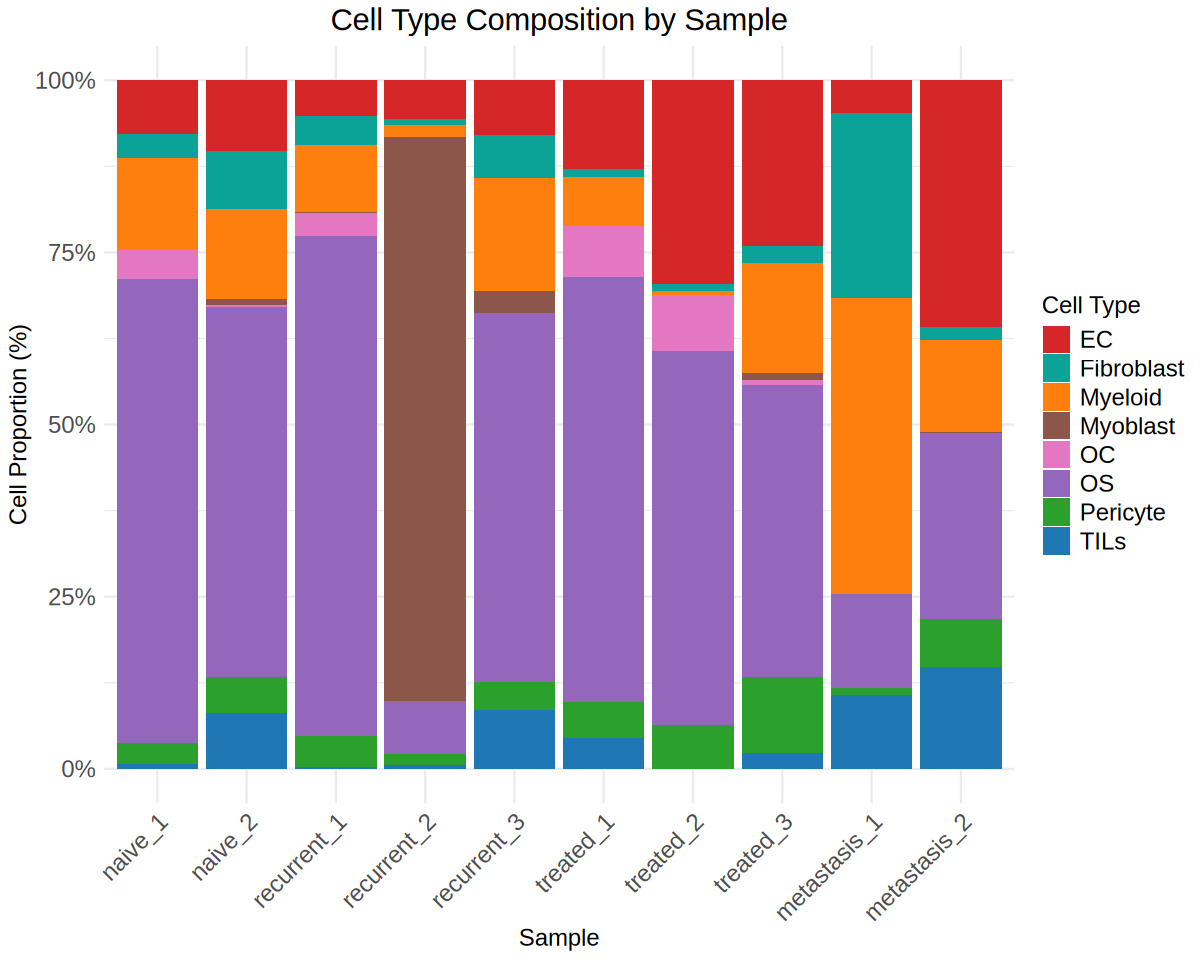

In [74]:
# Plot the stacked bar plot with custom colors
ggplot(data_summary, aes(x = seq_folder, y = proportion, fill = cell_type)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = cell_type_palette) + # Apply the custom color palette
  scale_y_continuous(labels = scales::percent) +
  labs(
    x = "Sample",
    y = "Cell Proportion (%)",
    fill = "Cell Type",
    title = "Cell Type Composition by Sample"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 14),
    axis.text.y = element_text(size = 14),
    axis.title = element_text(size = 14),
    plot.title = element_text(size = 18, hjust = 0.5),
    legend.text = element_text(size = 14),
    legend.title = element_text(size = 14)
  )

In [63]:
# Group and calculate proportions
data_summary_2 <- data %>%
  group_by(orig.ident, cell_type) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(orig.ident) %>%
  mutate(proportion = count / sum(count))

In [65]:
data_summary_2 |> head()

orig.ident,cell_type,count,proportion
<fct>,<chr>,<int>,<dbl>
metastasis,EC,2432,0.1588815575
metastasis,Fibroblast,2370,0.1548311230
metastasis,Myeloid,4381,0.2862089240
metastasis,Myoblast,5,0.0003266479
metastasis,OC,6,0.0003919775
metastasis,OS,2667,0.1742340106


In [66]:
# Plot the stacked bar plot with custom colors
ggplot(data_summary, aes(x = orig.ident, y = proportion, fill = cell_type)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = cell_type_palette) + # Apply the custom color palette
  scale_y_continuous(labels = scales::percent) +
  labs(
    x = "Group",
    y = "Cell Proportion (%)",
    fill = "Cell Type",
    title = "Cell Type Composition by Sample"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
    axis.text.y = element_text(size = 12),
    axis.title = element_text(size = 14),
    plot.title = element_text(size = 16, hjust = 0.5),
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 14)
  )

ERROR while rich displaying an object: Error in `geom_bar()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error:
! object 'orig.ident' not found

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
